# Nonlinear Rao-Style PC-CNN — 20-Class Regularized Experiment

In [1]:
import copy
import torch
import torch.nn.functional as F

from collections import defaultdict
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, Subset

import src.data_cleaning_and_preprocessing._model_ready_dataset as model_ready_dataset
from src.dataset.tiny_imagenet_dataset import TinyImageNetLoader
from archive.py_file.pc_supervised_rao_nonlinear_v2 import HierarchicalPCCNN

In [2]:
SEED = 42
BATCH_SIZE = 16
IMAGE_SIZE = 64

NUM_CLASSES = 20
TRAIN_IMAGES_PER_CLASS = 200
VAL_IMAGES_PER_CLASS = 50
TEST_IMAGES_PER_CLASS = 50

PC_EPOCHS = 10
INFERENCE_STEPS = 50
SUPERVISED_NUDGE_STEPS = 10

SIGMA_CLASS_SQ = 1.0
CLASS_LEARNING_RATE = 0.01
CLASS_WEIGHT_DECAY = 0.001

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.backends.mps.is_available() and hasattr(torch.mps, "manual_seed"):
    torch.mps.manual_seed(SEED)

print("Device:", device)

Device: mps


In [4]:
cleaned_tiny_imagenet = model_ready_dataset.ModelReadyDatasetLoader(TinyImageNetLoader(seed=SEED),
                                                                    image_size=IMAGE_SIZE).load()

train_dataset = cleaned_tiny_imagenet[0]
test_dataset = cleaned_tiny_imagenet[1]
selected_classes = list(range(NUM_CLASSES))

print("Full training dataset:", len(train_dataset))
print("Full held-out dataset:", len(test_dataset))

Full training dataset: 99953
Full held-out dataset: 9993


In [5]:
class_indices = defaultdict(list)

for i in range(len(train_dataset)):
    _, label = train_dataset[i]
    label = int(label)
    if label in selected_classes:
        class_indices[label].append(i)

split_generator = torch.Generator().manual_seed(SEED)
train_indices = []
val_indices = []

for class_id in selected_classes:
    available_indices = class_indices[class_id]
    required_images = TRAIN_IMAGES_PER_CLASS + VAL_IMAGES_PER_CLASS
    if len(available_indices) < required_images:
        raise ValueError(
            f"Class {class_id} has only {len(available_indices)} images, but {required_images} are required.")
    permutation = torch.randperm(len(available_indices), generator=split_generator)
    train_indices.extend([available_indices[i] for i in permutation[:TRAIN_IMAGES_PER_CLASS].tolist()])
    val_indices.extend([available_indices[i] for i in
                        permutation[TRAIN_IMAGES_PER_CLASS:TRAIN_IMAGES_PER_CLASS + VAL_IMAGES_PER_CLASS].tolist()])

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(train_dataset, val_indices)

assert len(set(train_indices).intersection(set(val_indices))) == 0
assert len(train_subset) == NUM_CLASSES * TRAIN_IMAGES_PER_CLASS
assert len(val_subset) == NUM_CLASSES * VAL_IMAGES_PER_CLASS

train_loader_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, generator=train_loader_generator)
train_eval_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)

K2_DECAYS_PER_EPOCH = 1.5
K2_DECAY_INTERVAL = max(1, round(len(train_subset) / K2_DECAYS_PER_EPOCH))

print("Training images:", len(train_subset))
print("Validation images:", len(val_subset))
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("k2 decays per epoch:", K2_DECAYS_PER_EPOCH)
print("k2 decay interval:", K2_DECAY_INTERVAL)

Training images: 4000
Validation images: 1000
Training batches: 250
Validation batches: 63
k2 decays per epoch: 1.5
k2 decay interval: 2667


In [6]:
test_class_indices = defaultdict(list)

for i in range(len(test_dataset)):
    _, label = test_dataset[i]
    label = int(label)
    if label in selected_classes:
        test_class_indices[label].append(i)

test_generator = torch.Generator().manual_seed(SEED)
test_indices = []

for class_id in selected_classes:
    available_indices = test_class_indices[class_id]
    if len(available_indices) < TEST_IMAGES_PER_CLASS:
        raise ValueError(
            f"Test class {class_id} has only {len(available_indices)} images, but {TEST_IMAGES_PER_CLASS} were requested.")
    permutation = torch.randperm(len(available_indices), generator=test_generator)
    test_indices.extend([available_indices[i] for i in permutation[:TEST_IMAGES_PER_CLASS].tolist()])

test_subset = Subset(test_dataset, test_indices)
test_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False)

print("Test images:", len(test_subset))
print("Test batches:", len(test_loader))

Test images: 1000
Test batches: 63


In [7]:
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.backends.mps.is_available() and hasattr(torch.mps, "manual_seed"):
    torch.mps.manual_seed(SEED)

model = HierarchicalPCCNN(
    num_classes=NUM_CLASSES, input_size=IMAGE_SIZE, inference_steps=INFERENCE_STEPS,
    supervised_nudge_steps=SUPERVISED_NUDGE_STEPS, convergence_tolerance=1e-5,
    sigma_class_sq=SIGMA_CLASS_SQ, class_learning_rate=CLASS_LEARNING_RATE,
    lambda_class=CLASS_WEIGHT_DECAY, k2_decay_interval=K2_DECAY_INTERVAL).to(device)

initial_u1 = model.level1["conv"].weight.detach().cpu().clone()
initial_u2 = model.level2["conv"].weight.detach().cpu().clone()
initial_u3 = model.level3["conv"].weight.detach().cpu().clone()
initial_wc = model.classifier.weight.detach().cpu().clone()
initial_bc = model.classifier.bias.detach().cpu().clone()

print("class_learning_rate:", model.class_learning_rate)
print("lambda_class:", model.lambda_class)
print("k2 decay interval:", model.k2_decay_interval)
print("Total unique parameters:", sum(parameter.numel() for parameter in model.parameters()))
print("Autograd-enabled parameters:",
      sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad))

class_learning_rate: 0.01
lambda_class: 0.001
k2 decay interval: 2667
Total unique parameters: 660340
Autograd-enabled parameters: 0


In [8]:
@torch.no_grad()
def evaluate_model(model: HierarchicalPCCNN, data_loader, device, name=""):
    total_loss = 0.0
    total_correct = 0
    total_images = 0
    total_steps = 0
    total_converged = 0
    model.eval()

    for images, labels in tqdm(data_loader, desc=f"Evaluation Nonlinear Rao PC-CNN - {name}"):
        images = images.to(device)
        labels = labels.to(device=device, dtype=torch.long)
        result = model.classify_batch(images)
        probabilities = result["probabilities"]
        predictions = result["predictions"]
        true_probabilities = probabilities[torch.arange(labels.shape[0], device=labels.device), labels]
        loss = -torch.log(true_probabilities + 1e-8).mean().item()
        total_loss += loss * labels.shape[0]
        total_correct += (predictions == labels).sum().item()
        total_images += labels.shape[0]
        total_steps += sum(result["inference_steps"])
        total_converged += sum(int(value) for value in result["converged"])

    return total_loss / total_images, 100.0 * total_correct / total_images, total_steps / total_images, 100.0 * total_converged / total_images

In [ ]:
original_inference_steps = model.inference_steps

model.inference_steps = 50
val_loss_50, val_accuracy_50, val_steps_50, val_convergence_50 = evaluate_model(model, val_loader, device, "Validation 50 Steps")

model.inference_steps = 100
val_loss_100, val_accuracy_100, val_steps_100, val_convergence_100 = evaluate_model(model, val_loader, device, "Validation 100 Steps")

model.inference_steps = original_inference_steps

print("50 steps  :", f"Accuracy={val_accuracy_50:.2f}% | Loss={val_loss_50:.4f} | Convergence={val_convergence_50:.2f}%")
print("100 steps :", f"Accuracy={val_accuracy_100:.2f}% | Loss={val_loss_100:.4f} | Convergence={val_convergence_100:.2f}%")

In [9]:
import matplotlib.pyplot as plt

@torch.no_grad()
def show_reconstructions(model: HierarchicalPCCNN, dataset, device, num_images=5):
    def to_display(image):
        image = image.detach().cpu()
        image = image.clamp(0, 1)
        return image.permute(1, 2, 0).numpy()

    model.eval()

    fig, axes = plt.subplots(num_images, 2, figsize=(8, 4 * num_images))

    for i in range(num_images):
        image, label = dataset[i]
        result = model.reconstruct(image.to(device))

        original = to_display(image)
        reconstructed = to_display(result["reconstruction"])

        axes[i, 0].imshow(original)
        axes[i, 0].set_title(f"Original | Class {int(label)}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(reconstructed)
        axes[i, 1].set_title(f"Reconstructed | Predicted {result['predicted_class']}")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

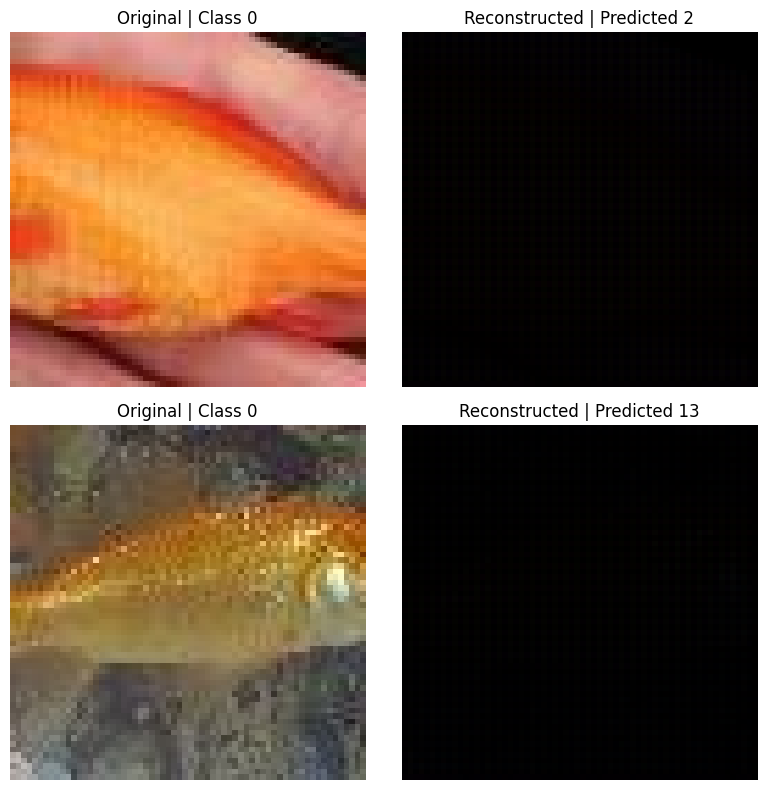

In [10]:
show_reconstructions(model, val_subset, device, num_images=2)

In [11]:
history = []
best_val_accuracy = -1.0
best_val_loss = float("inf")
best_epoch = None
best_model_state = None
best_k2 = None
best_training_input_count = None

for epoch in range(PC_EPOCHS):
    total_error_0 = 0.0
    total_error_1 = 0.0
    total_error_2 = 0.0
    total_class_error = 0.0
    total_nudged_error_0 = 0.0
    total_nudged_error_1 = 0.0
    total_nudged_error_2 = 0.0
    total_class_loss = 0.0
    total_images = 0
    model.train()

    for images, labels in tqdm(train_loader, desc=f"Nonlinear Rao PC-CNN Epoch {epoch + 1}/{PC_EPOCHS}"):
        for image, label in zip(images, labels):
            image = image.to(device)
            label = label.to(device=device, dtype=torch.long)
            result = model(image, label)
            total_error_0 += result["error_0"]
            total_error_1 += result["error_1"]
            total_error_2 += result["error_2"]
            total_class_error += result["class_error"]
            total_nudged_error_0 += result["nudged_error_0"]
            total_nudged_error_1 += result["nudged_error_1"]
            total_nudged_error_2 += result["nudged_error_2"]
            total_class_loss += result["class_loss"]
            total_images += 1

    mean_error_0 = total_error_0 / total_images
    mean_error_1 = total_error_1 / total_images
    mean_error_2 = total_error_2 / total_images
    mean_class_error = total_class_error / total_images
    mean_nudged_error_0 = total_nudged_error_0 / total_images
    mean_nudged_error_1 = total_nudged_error_1 / total_images
    mean_nudged_error_2 = total_nudged_error_2 / total_images
    mean_class_loss = total_class_loss / total_images

    train_loss, train_accuracy, train_steps, train_convergence = evaluate_model(model, train_eval_loader, device, "Train")
    val_loss, val_accuracy, val_steps, val_convergence = evaluate_model(model, val_loader, device, "Validation")

    history.append({
        "epoch": epoch + 1, "train_loss": train_loss, "train_accuracy": train_accuracy,
        "val_loss": val_loss, "val_accuracy": val_accuracy, "k2": model.k2
    })

    is_better = val_loss < best_val_loss
    if val_loss == best_val_loss and val_accuracy > best_val_accuracy:
        is_better = True

    if is_better:
        best_val_accuracy = val_accuracy
        best_val_loss = val_loss
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())
        best_k2 = model.k2
        best_training_input_count = model.training_input_count

    print(
        f"Epoch {epoch + 1}/{PC_EPOCHS} | e0: {mean_error_0:.6f} | e1: {mean_error_1:.6f} | e2: {mean_error_2:.6f} | Class e: {mean_class_error:.6f} | Nudge e0: {mean_nudged_error_0:.6f} | Nudge e1: {mean_nudged_error_1:.6f} | Nudge e2: {mean_nudged_error_2:.6f}")
    print(
        f"Class Loss: {mean_class_loss:.4f} | Train Acc: {train_accuracy:.2f}% | Val Acc: {val_accuracy:.2f}% | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | k2: {model.k2:.8f}")
    print(f"Train Convergence: {train_convergence:.2f}% | Val Convergence: {val_convergence:.2f}%")

Nonlinear Rao PC-CNN Epoch 1/10:   0%|          | 0/250 [00:00<?, ?it/s]

Evaluation Nonlinear Rao PC-CNN - Train:   0%|          | 0/250 [00:00<?, ?it/s]

Evaluation Nonlinear Rao PC-CNN - Validation:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 1/10 | e0: 0.091491 | e1: 0.040181 | e2: 0.025926 | Class e: 0.213669 | Nudge e0: 0.088478 | Nudge e1: 0.042235 | Nudge e2: 0.028589
Class Loss: 2.8689 | Train Acc: 21.45% | Val Acc: 17.30% | Train Loss: 2.6164 | Val Loss: 2.7603 | k2: 0.98522167
Train Convergence: 0.00% | Val Convergence: 0.00%


Nonlinear Rao PC-CNN Epoch 2/10:   0%|          | 0/250 [00:00<?, ?it/s]

...

Epoch 9/10 | e0: 0.048896 | e1: 0.037072 | e2: 0.028319 | Class e: 0.186229 | Nudge e0: 0.042999 | Nudge e1: 0.038050 | Nudge e2: 0.032261
Class Loss: 2.0206 | Train Acc: 46.38% | Val Acc: 19.50% | Train Loss: 1.9021 | Val Loss: 2.7377 | k2: 0.82402702
Train Convergence: 0.00% | Val Convergence: 0.00%


Nonlinear Rao PC-CNN Epoch 10/10:   0%|          | 0/250 [00:00<?, ?it/s]

Evaluation Nonlinear Rao PC-CNN - Train:   0%|          | 0/250 [00:00<?, ?it/s]

Evaluation Nonlinear Rao PC-CNN - Validation:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 10/10 | e0: 0.048867 | e1: 0.036916 | e2: 0.028372 | Class e: 0.185034 | Nudge e0: 0.042970 | Nudge e1: 0.037848 | Nudge e2: 0.032334
Class Loss: 1.9803 | Train Acc: 46.73% | Val Acc: 19.90% | Train Loss: 1.8998 | Val Loss: 2.7683 | k2: 0.81184928
Train Convergence: 0.00% | Val Convergence: 0.00%


In [12]:
print("AFTER TRAINING")
print("Inference Steps: ", model.inference_steps)
print("training_input_count:", model.training_input_count)
print("k2:", model.k2)
print("U1 norm:", model.level1["conv"].weight.norm().item())
print("U2 norm:", model.level2["conv"].weight.norm().item())
print("U3 norm:", model.level3["conv"].weight.norm().item())
print("Wc norm:", model.classifier.weight.norm().item())
print("bc norm:", model.classifier.bias.norm().item())
print("U1 change:", torch.norm(model.level1["conv"].weight.detach().cpu() - initial_u1).item())
print("U2 change:", torch.norm(model.level2["conv"].weight.detach().cpu() - initial_u2).item())
print("U3 change:", torch.norm(model.level3["conv"].weight.detach().cpu() - initial_u3).item())
print("Wc change:", torch.norm(model.classifier.weight.detach().cpu() - initial_wc).item())
print("bc change:", torch.norm(model.classifier.bias.detach().cpu() - initial_bc).item())

AFTER TRAINING
Inference Steps:  50
training_input_count: 40000
k2: 0.8118492774834585
U1 norm: 1.7473161220550537
U2 norm: 3.260484457015991
U3 norm: 3.8244197368621826
Wc norm: 16.018085479736328
bc norm: 3.1005146503448486
U1 change: 1.6551350355148315
U2 change: 3.466407299041748
U3 change: 6.306485652923584
Wc change: 15.694567680358887
bc change: 3.1005146503448486


In [13]:
# if best_model_state is None:
#     raise RuntimeError("No model checkpoint was saved.")
#
# model.load_state_dict(best_model_state)
# model.k2 = best_k2
# model.training_input_count = best_training_input_count
# model.eval()
#
# print("Best epoch:", best_epoch)
# print("Best validation accuracy:", f"{best_val_accuracy:.2f}%")
# print("Best validation loss:", f"{best_val_loss:.4f}")
# print("Best Wc norm:", model.classifier.weight.norm().item())
# print("Best k2:", model.k2)

Best epoch: 3
Best validation accuracy: 19.40%
Best validation loss: 2.6547
Best Wc norm: 9.067090034484863
Best k2: 0.9421842302867243


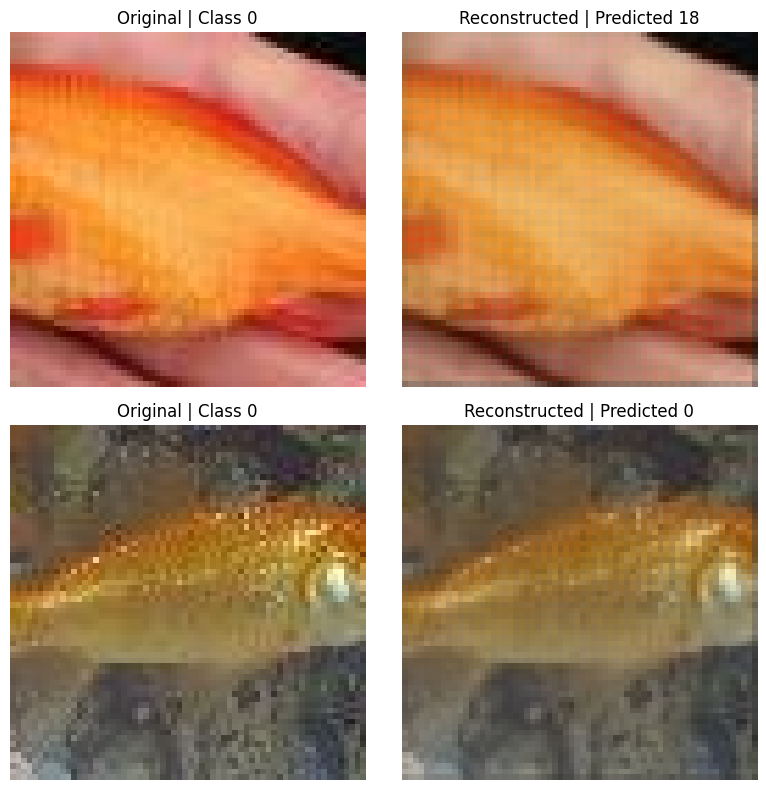

In [14]:
show_reconstructions(model, val_subset, device, num_images=2)

In [ ]:
original_inference_steps = model.inference_steps

model.inference_steps = 20
val_loss_20, val_accuracy_20, val_steps_20, val_convergence_20 = evaluate_model(model, val_loader, device, "Validation 20 Steps")

model.inference_steps = 50
val_loss_50, val_accuracy_50, val_steps_50, val_convergence_50 = evaluate_model(model, val_loader, device, "Validation 50 Steps")

model.inference_steps = 100
val_loss_100, val_accuracy_100, val_steps_100, val_convergence_100 = evaluate_model(model, val_loader, device, "Validation 100 Steps")

model.inference_steps = 200
val_loss_200, val_accuracy_200, val_steps_200, val_convergence_200 = evaluate_model(model, val_loader, device, "Validation 200 Steps")

model.inference_steps = 500
val_loss_500, val_accuracy_500, val_steps_500, val_convergence_500 = evaluate_model(model, val_loader, device, "Validation 500 Steps")

model.inference_steps = original_inference_steps

print("20 steps :", f"Accuracy={val_accuracy_20:.2f}% | Loss={val_loss_20:.4f} | Convergence={val_convergence_20:.2f}%")
print("50 steps :", f"Accuracy={val_accuracy_50:.2f}% | Loss={val_loss_50:.4f} | Convergence={val_convergence_50:.2f}%")
print("100 steps:", f"Accuracy={val_accuracy_100:.2f}% | Loss={val_loss_100:.4f} | Convergence={val_convergence_100:.2f}%")
print("200 steps:", f"Accuracy={val_accuracy_200:.2f}% | Loss={val_loss_200:.4f} | Convergence={val_convergence_200:.2f}%")
print("500 steps:", f"Accuracy={val_accuracy_500:.2f}% | Loss={val_loss_500:.4f} | Convergence={val_convergence_500:.2f}%")

In [15]:
@torch.no_grad()
def confidence_diagnostics(model, data_loader, device, name):
    model.eval()
    correct_confidences = []
    wrong_confidences = []
    true_class_probabilities = []

    for images, labels in tqdm(data_loader):
        images = images.to(device)
        labels = labels.to(device=device, dtype=torch.long)
        result = model.classify_batch(images)
        probabilities = result["probabilities"]
        predictions = result["predictions"]
        confidences = probabilities.max(dim=1).values
        true_probs = probabilities[torch.arange(labels.shape[0], device=device), labels]
        correct_mask = predictions == labels
        wrong_mask = predictions != labels
        correct_confidences.extend(confidences[correct_mask].cpu().tolist())
        wrong_confidences.extend(confidences[wrong_mask].cpu().tolist())
        true_class_probabilities.extend(true_probs.cpu().tolist())

    print(name)
    print("Mean true-class probability:", sum(true_class_probabilities) / len(true_class_probabilities))
    print("Mean confidence on correct predictions:",
          sum(correct_confidences) / len(correct_confidences) if correct_confidences else 0.0)
    print("Mean confidence on wrong predictions:",
          sum(wrong_confidences) / len(wrong_confidences) if wrong_confidences else 0.0)


confidence_diagnostics(model, train_eval_loader, device, "TRAIN")
confidence_diagnostics(model, val_loader, device, "VALIDATION")

  0%|          | 0/250 [00:00<?, ?it/s]

TRAIN
Mean true-class probability: 0.16670019516623688
Mean confidence on correct predictions: 0.3261868131717596
Mean confidence on wrong predictions: 0.1854169790554653


  0%|          | 0/63 [00:00<?, ?it/s]

VALIDATION
Mean true-class probability: 0.12248578313916005
Mean confidence on correct predictions: 0.36060189966534834
Mean confidence on wrong predictions: 0.19081642417694736


In [ ]:
print(model.inference_steps)

In [16]:
@torch.no_grad()
def collect_class_features(model, data_loader, device, num_classes):
    features_by_class = [[] for _ in range(num_classes)]
    model.eval()

    for images, labels in tqdm(data_loader, desc="Collecting FREE r3 Features"):
        for image, label in zip(images, labels):
            image = image.to(device)
            label = int(label)
            _, _, r3, _, _ = model.infer(image)
            features_by_class[label].append(model.class_features(r3).squeeze(0).detach().cpu())

    return [torch.stack(features) for features in features_by_class]


train_features_by_class = collect_class_features(model, train_eval_loader, device, NUM_CLASSES)
val_features_by_class = collect_class_features(model, val_loader, device, NUM_CLASSES)

In [17]:
print("train_features_by_class: ", train_features_by_class)
print("val_features_by_class: ", val_features_by_class)

train_features_by_class:  [tensor([[ 0.0009, -0.0147, -0.0082,  ..., -0.0086, -0.0010, -0.0543],
        [-0.0129, -0.0120, -0.0196,  ..., -0.0050, -0.0211, -0.0420],
        [-0.0432, -0.0066, -0.0045,  ...,  0.0761, -0.0268, -0.0994],
        ...,
        [-0.0052, -0.0144, -0.0130,  ..., -0.0873, -0.1134, -0.0902],
        [-0.0065, -0.0076,  0.0056,  ..., -0.0079, -0.0019, -0.0089],
        [-0.0504, -0.0187, -0.0157,  ..., -0.0044,  0.0040, -0.0251]]), tensor([[-0.0723, -0.0529, -0.0492,  ..., -0.0437,  0.0147,  0.0707],
        [-0.0115, -0.0646, -0.0240,  ..., -0.0183,  0.0016, -0.0179],
        [-0.0640, -0.0734, -0.0319,  ..., -0.0298,  0.0147, -0.0530],
        ...,
        [-0.0644, -0.0778, -0.0765,  ...,  0.0314,  0.0500,  0.0721],
        [-0.0085, -0.0386, -0.0761,  ..., -0.0748, -0.0205, -0.1067],
        [-0.0300, -0.0780, -0.0407,  ..., -0.0165, -0.0544, -0.0035]]), tensor([[-0.0747, -0.0876, -0.0761,  ..., -0.0331, -0.0106, -0.0236],
        [-0.0334, -0.0371, -0.046

In [18]:
@torch.no_grad()
def compare_feature_geometry(train_features_by_class, val_features_by_class):
    train_centroids = torch.stack([features.mean(dim=0) for features in train_features_by_class])
    val_centroids = torch.stack([features.mean(dim=0) for features in val_features_by_class])
    train_spread = torch.tensor(
        [torch.norm(features - train_centroids[class_id], dim=1).mean().item() for class_id, features in
         enumerate(train_features_by_class)])
    val_spread_to_train = torch.tensor(
        [torch.norm(features - train_centroids[class_id], dim=1).mean().item() for class_id, features in
         enumerate(val_features_by_class)])
    centroid_shift = torch.norm(val_centroids - train_centroids, dim=1)
    train_centroid_distances = torch.cdist(train_centroids, train_centroids)
    off_diagonal_mask = ~torch.eye(NUM_CLASSES, dtype=torch.bool)
    inter_class_distances = train_centroid_distances[off_diagonal_mask]
    mean_inter_class_distance = inter_class_distances.mean().item()
    minimum_inter_class_distance = inter_class_distances.min().item()
    mean_train_spread = train_spread.mean().item()
    mean_val_spread = val_spread_to_train.mean().item()
    mean_centroid_shift = centroid_shift.mean().item()
    train_separation_ratio = mean_inter_class_distance / mean_train_spread
    val_separation_ratio = mean_inter_class_distance / mean_val_spread

    def nearest_centroid_accuracy(features_by_class, centroids, metric="euclidean"):
        correct = 0
        total = 0
        normalized_centroids = F.normalize(centroids, dim=1)
        for class_id, features in enumerate(features_by_class):
            predictions = torch.cdist(features, centroids).argmin(dim=1) if metric == "euclidean" else (
                        F.normalize(features, dim=1) @ normalized_centroids.T).argmax(dim=1)
            correct += (predictions == class_id).sum().item()
            total += features.shape[0]
        return 100.0 * correct / total

    train_nc_euclidean = nearest_centroid_accuracy(train_features_by_class, train_centroids, "euclidean")
    val_nc_euclidean = nearest_centroid_accuracy(val_features_by_class, train_centroids, "euclidean")
    train_nc_cosine = nearest_centroid_accuracy(train_features_by_class, train_centroids, "cosine")
    val_nc_cosine = nearest_centroid_accuracy(val_features_by_class, train_centroids, "cosine")

    print("=" * 78)
    print("FREE r3 TRAIN vs VALIDATION REPRESENTATION DIAGNOSTICS")
    print("=" * 78)
    print(f"Mean TRAIN within-class spread          : {mean_train_spread:.4f}")
    print(f"Mean VAL distance to TRAIN centroid     : {mean_val_spread:.4f}")
    print(f"Mean TRAIN↔VAL centroid shift           : {mean_centroid_shift:.4f}")
    print(f"Mean TRAIN inter-class centroid distance: {mean_inter_class_distance:.4f}")
    print(f"Minimum inter-class centroid distance   : {minimum_inter_class_distance:.4f}")
    print(f"TRAIN separation ratio                  : {train_separation_ratio:.4f}")
    print(f"VALIDATION separation ratio             : {val_separation_ratio:.4f}")
    print("-" * 78)
    print(f"TRAIN nearest-centroid accuracy (Euclidean): {train_nc_euclidean:.2f}%")
    print(f"VAL nearest-centroid accuracy (Euclidean)  : {val_nc_euclidean:.2f}%")
    print(f"TRAIN nearest-centroid accuracy (Cosine)   : {train_nc_cosine:.2f}%")
    print(f"VAL nearest-centroid accuracy (Cosine)     : {val_nc_cosine:.2f}%")
    print("-" * 78)

    for class_id in range(NUM_CLASSES):
        print(
            f"Class {class_id:02d} | Train Spread: {train_spread[class_id]:.4f} | Val→Train Spread: {val_spread_to_train[class_id]:.4f} | Centroid Shift: {centroid_shift[class_id]:.4f}")

    print("=" * 78)


compare_feature_geometry(train_features_by_class, val_features_by_class)

FREE r3 TRAIN vs VALIDATION REPRESENTATION DIAGNOSTICS
Mean TRAIN within-class spread          : 5.3779
Mean VAL distance to TRAIN centroid     : 5.3422
Mean TRAIN↔VAL centroid shift           : 0.8616
Mean TRAIN inter-class centroid distance: 1.8967
Minimum inter-class centroid distance   : 0.5936
TRAIN separation ratio                  : 0.3527
VALIDATION separation ratio             : 0.3551
------------------------------------------------------------------------------
TRAIN nearest-centroid accuracy (Euclidean): 24.15%
VAL nearest-centroid accuracy (Euclidean)  : 20.10%
TRAIN nearest-centroid accuracy (Cosine)   : 26.20%
VAL nearest-centroid accuracy (Cosine)     : 20.60%
------------------------------------------------------------------------------
Class 00 | Train Spread: 5.8623 | Val→Train Spread: 5.5803 | Centroid Shift: 0.8791
Class 01 | Train Spread: 5.2474 | Val→Train Spread: 5.3778 | Centroid Shift: 0.9684
Class 02 | Train Spread: 4.8915 | Val→Train Spread: 4.9703 | Centroi

In [ ]:
train_loss, train_accuracy, train_steps, train_convergence = evaluate_model(model, train_eval_loader, device,
                                                                            "Train Final")
val_loss, val_accuracy, val_steps, val_convergence = evaluate_model(model, val_loader, device, "Validation Final")
test_loss, test_accuracy, test_steps, test_convergence = evaluate_model(model, test_loader, device, "Test")

print("FINAL RESTORED BEST MODEL")
print("Train Loss:", f"{train_loss:.4f}")
print("Train Accuracy:", f"{train_accuracy:.2f}%")
print("Validation Loss:", f"{val_loss:.4f}")
print("Validation Accuracy:", f"{val_accuracy:.2f}%")
print("Test Loss:", f"{test_loss:.4f}")
print("Test Accuracy:", f"{test_accuracy:.2f}%")
print("Test Convergence:", f"{test_convergence:.2f}%")